In [ ]:
# ================================
# Crop Recommendation System
# Complete Machine Learning Project
# ================================


# ================================
# Import Libraries
# ================================
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [ ]:
# ================================
# Load Dataset
# ================================
crop = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\crop_recommendation system\Crop_recommendation (2).csv")

print(crop.head())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [ ]:
# ================================
# Basic Information
# ================================

print(crop.shape)

print(crop.info())

print(crop.isnull().sum())

print(crop.describe())

(2200, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32

In [ ]:
# ================================
# Check Crop Distribution
# ================================

print(crop['label'].value_counts())

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


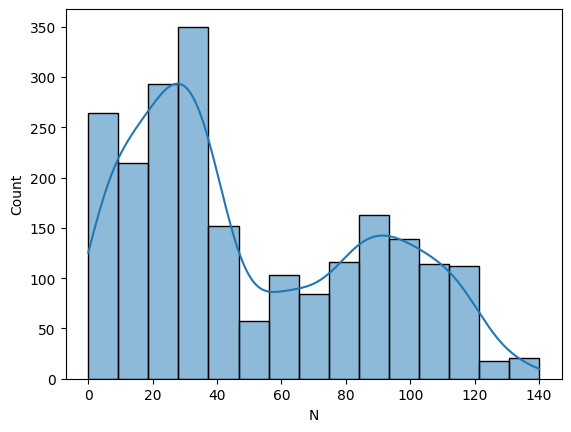

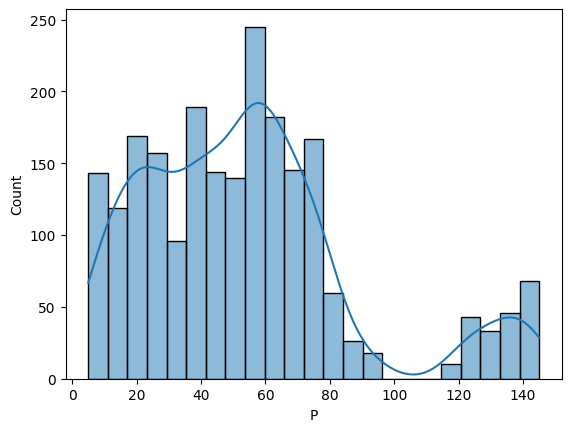

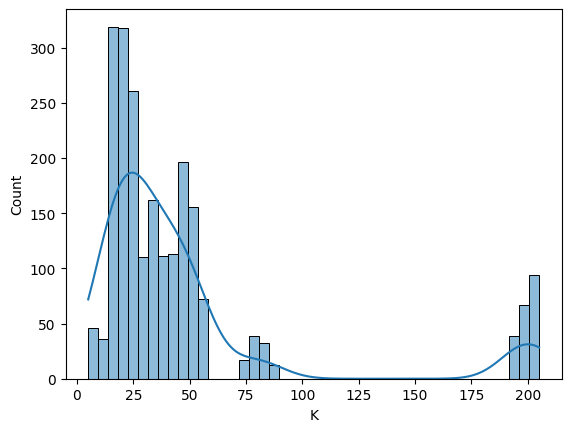

In [ ]:

# ================================
# Data Visualization
# ================================

sns.histplot(crop['N'], kde=True)
plt.show()

sns.histplot(crop['P'], kde=True)
plt.show()

sns.histplot(crop['K'], kde=True)
plt.show()

In [ ]:
# ================================
# Convert Label into Numeric
# ================================

crop_dict = {
    'rice': 1,
    'maize': 2,
    'jute': 3,
    'cotton': 4,
    'coconut': 5,
    'papaya': 6,
    'orange': 7,
    'apple': 8,
    'muskmelon': 9,
    'watermelon': 10,
    'grapes': 11,
    'mango': 12,
    'banana': 13,
    'pomegranate': 14,
    'lentil': 15,
    'blackgram': 16,
    'mungbean': 17,
    'mothbeans': 18,
    'pigeonpeas': 19,
    'kidneybeans': 20,
    'chickpea': 21,
    'coffee': 22
}

crop['crop_num'] = crop['label'].map(crop_dict)

print(crop.head())


    N   P   K  temperature   humidity        ph    rainfall label  crop_num
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice         1
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice         1
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice         1
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice         1
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice         1


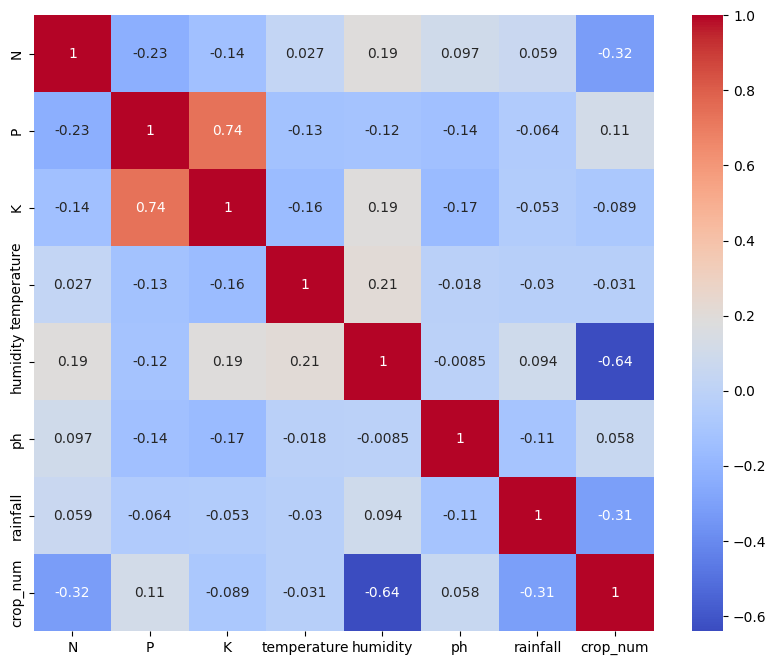

In [ ]:
# ================================
# Correlation Matrix
# ================================

corr = crop.drop('label', axis=1).corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.show()


In [ ]:
print(corr)

                    N         P         K  temperature  humidity        ph  \
N            1.000000 -0.231460 -0.140512     0.026504  0.190688  0.096683   
P           -0.231460  1.000000  0.736232    -0.127541 -0.118734 -0.138019   
K           -0.140512  0.736232  1.000000    -0.160387  0.190859 -0.169503   
temperature  0.026504 -0.127541 -0.160387     1.000000  0.205320 -0.017795   
humidity     0.190688 -0.118734  0.190859     0.205320  1.000000 -0.008483   
ph           0.096683 -0.138019 -0.169503    -0.017795 -0.008483  1.000000   
rainfall     0.059020 -0.063839 -0.053461    -0.030084  0.094423 -0.109069   
crop_num    -0.317076  0.109993 -0.089209    -0.031383 -0.640925  0.057527   

             rainfall  crop_num  
N            0.059020 -0.317076  
P           -0.063839  0.109993  
K           -0.053461 -0.089209  
temperature -0.030084 -0.031383  
humidity     0.094423 -0.640925  
ph          -0.109069  0.057527  
rainfall     1.000000 -0.311053  
crop_num    -0.311053  1.

In [ ]:
# ================================
# Features and Target
# ================================

X = crop.drop(['label', 'crop_num'], axis=1)

y = crop['crop_num']

print(X.head())

print(y.head())


    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340
0    1
1    1
2    1
3    1
4    1
Name: crop_num, dtype: int64


In [ ]:
# ================================
# Train Test Split
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(1760, 7)
(440, 7)


In [ ]:
# ================================
# Feature Scaling
# ================================

ms = MinMaxScaler()

X_train = ms.fit_transform(X_train)

X_test = ms.transform(X_test)


In [ ]:
# ================================
# Create Models
# ================================

models = {

    'Logistic Regression': LogisticRegression(max_iter=1000),

    'Naive Bayes': GaussianNB(),

    'K-Nearest Neighbors': KNeighborsClassifier(),

}

In [ ]:
# ================================
# Train and Evaluate Models
# ================================

for name, model in models.items():

    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    ypred = model.predict(X_test)

    # Accuracy
    print(f"{name} Accuracy : {accuracy_score(y_test, ypred)}")

    # Confusion Matrix
    print("Confusion Matrix : ")

    print(confusion_matrix(y_test, ypred))

    # Classification Report
    print("Classification Report : ")

    print(classification_report(y_test, ypred))

    print("==================================================")


Logistic Regression Accuracy : 0.9181818181818182
Confusion Matrix : 
[[16  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 6  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 3  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  3  0  0  0  0  0]
 [ 0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  

In [ ]:
# ================================
# Final Model Training
# ================================

final_model = GaussianNB()

final_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
# Reverse the crop_dict for decoding
crop_dict_reverse = {v: k for k, v in crop_dict.items()}

def recommendation(N, P, K, temperature, humidity, ph, rainfall):

    features = pd.DataFrame(
        [[N, P, K, temperature, humidity, ph, rainfall]],
        columns=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
    )

    # Scale input data
    transformed_features = ms.transform(features)

    # Predict encoded label
    prediction = final_model.predict(transformed_features)

    # Convert encoded label to crop name using crop_dict_reverse
    crop_name = crop_dict_reverse[prediction[0]]

    return crop_name

In [ ]:
# INPUT VALUES
# =========================
N = 102
P = 28
K = 54
temperature = 25.15623099
humidity = 80.27525115
ph = 6.862157042
rainfall = 55.49541453

# =========================
# PREDICTION
# =========================
predict = recommendation(
    N,
    P,
    K,
    temperature,
    humidity,
    ph,
    rainfall
)

print("Recommended Crop :", predict)

Recommended Crop : watermelon


In [ ]:
predict = recommendation(90, 42, 43, 20.87, 82.00, 6.50, 202.93)
print("Recommended Crop :", predict)

Recommended Crop : rice


In [ ]:
predict = recommendation(20, 27, 30, 31.50, 50.23, 6.10, 94.50)
print("Recommended Crop :", predict)

Recommended Crop : mango


In [ ]:
predict = recommendation(103, 18, 30, 26.77, 58.99, 6.75, 158.07)
print("Recommended Crop :", predict)

Recommended Crop : coffee


In [ ]:
predict = recommendation(99, 17, 50, 24.86, 85.16, 6.50, 40.10)
print("Recommended Crop :", predict)

Recommended Crop : watermelon


In [ ]:
# ================================
# Test Cases with Expected Output
# ================================

test_cases = [
    (90, 42, 43, 20.87, 82.00, 6.50, 202.93, 'rice'),
    (20, 27, 30, 31.50, 50.23, 6.10, 94.50,  'mango'),
    (103, 18, 30, 26.77, 58.99, 6.75, 158.07, 'coffee'),
    (99, 17, 50, 24.86, 85.16, 6.50, 40.10,  'watermelon'),
    (100, 82, 50, 27.38, 80.00, 5.97, 105.92, 'banana'),
]

print("=" * 55)
print(f"{'Test':<6} {'Expected':<15} {'Predicted':<15} {'Result'}")
print("=" * 55)

passed = 0
failed = 0

for i, (N, P, K, temp, hum, ph, rain, expected) in enumerate(test_cases, 1):
    predicted = recommendation(N, P, K, temp, hum, ph, rain)
    status = "✅ PASS" if predicted == expected else "❌ FAIL"
    
    if predicted == expected:
        passed += 1
    else:
        failed += 1
    
    print(f"{i:<6} {expected:<15} {predicted:<15} {status}")

print("=" * 55)
print(f"Total: {len(test_cases)} | Passed: {passed} | Failed: {failed}")
print("=" * 55)

Test   Expected        Predicted       Result
1      rice            rice            ✅ PASS
2      mango           mango           ✅ PASS
3      coffee          coffee          ✅ PASS
4      watermelon      watermelon      ✅ PASS
5      banana          banana          ✅ PASS
Total: 5 | Passed: 5 | Failed: 0


In [ ]:
import pickle

# Save model
pickle.dump(final_model, open('model.pkl', 'wb'))

# Save scaler
pickle.dump(ms, open('scaler.pkl', 'wb'))

print("Model and Scaler Saved Successfully")

Model and Scaler Saved Successfully
